In [5]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Библиотеки для обработки текста и построения TF-IDF признаков
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
# функций для разделения данных и оценки модели
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
# NMF для уменьшения размерности (сохранение неотрицательности)
from sklearn.decomposition import NMF
from matplotlib.colors import ListedColormap
import seaborn as sns


In [4]:

# Загружаем датасет "spam.csv", который содержит информацию о спаме и не спаме.
df = pd.read_csv("../data/spam.csv", encoding="latin-1")
# Оставляем только нужные колонки для анализа
df = df[['Category', 'Message']]

# Преобразуем метки: 'ham' → 0 (не спам), 'spam' → 1 (спам)
df['Label'] = df['Category'].map({'ham': 0, 'spam': 1})

# Выводим первые строки датасета для проверки корректности загрузки и преобразования
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 100)

In [3]:
print(df.head())

  Category                                            Message  Label
0      ham  Go until jurong point, crazy.. Available only ...      0
1      ham                      Ok lar... Joking wif u oni...      0
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...      1
3      ham  U dun say so early hor... U c already then say...      0
4      ham  Nah I don't think he goes to usf, he lives aro...      0


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
 2   Label     5572 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 130.7+ KB
None


In [5]:
print(df.describe())

             Label
count  5572.000000
mean      0.134063
std       0.340751
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       1.000000


In [6]:
# Преобразуем текст сообщений в числовые признаки с помощью TF-IDF векторизации.
# TF-IDF (Term Frequency - Inverse Document Frequency) позволяет оценить значимость каждого слова
# в документе относительно всего корпуса, исключая слишком часто встречающиеся слова.
vectorizer = TfidfVectorizer(stop_words='english')
X_features = vectorizer.fit_transform(df['Message'])  # Получаем разреженную матрицу признаков
y = df['Label'].values  # Целевая переменная: 0 – не спам, 1 – спам

In [7]:
# Делим данные на обучающую и тестовую выборки в соотношении 70/30.
X_train, X_test, y_train, y_test = train_test_split(X_features, y, test_size=0.3, random_state=42)

# Инициализируем модель Комплементарного наивного Байеса
clf = ComplementNB(alpha=1.0)
clf.fit(X_train, y_train)

# Получаем предсказания модели на тестовой выборке
y_pred = clf.predict(X_test)

# precision (Точность)
# recall (Полнота) - Показывает, насколько хорошо модель находит все объекты данного класса.
# f1-score (F1-мера) -Среднее гармоническое между precision и recall
# support -Количество объектов в тестовой выборке для каждого класса.
# accuracy (Точность модели в целом)
# macro avg (Среднее арифметическое для всех классов)
# weighted avg (Средневзвешенное значение по количеству объектов в классах)
acc = accuracy_score(y_test, y_pred)
print("\nРезультаты модели на тестовой выборке:")
print("Accuracy:", acc)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Результаты модели на тестовой выборке:
Accuracy: 0.9318181818181818
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.93      0.96      1448
           1       0.67      0.97      0.79       224

    accuracy                           0.93      1672
   macro avg       0.83      0.95      0.88      1672
weighted avg       0.95      0.93      0.94      1672

Confusion Matrix:
 [[1341  107]
 [   7  217]]


In [21]:

X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

# Применяем NMF для уменьшения размерности до 2-х компонент
nmf = NMF(n_components=2, random_state=42)
X_train_nmf = nmf.fit_transform(X_train_dense)
X_test_nmf = nmf.transform(X_test_dense)

# Обучаем новый экземпляр модели ComplementNB на данных, преобразованных с помощью NMF.
clf_nmf = ComplementNB(alpha=1.0)
clf_nmf.fit(X_train_nmf, y_train)

def plot_decision_boundary(clf, X, y, title, step=0.01):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                         np.arange(y_min, y_max, step))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(('lightgreen', 'salmon')))
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

    for i, j in enumerate(np.unique(y)):
        plt.scatter(X[y == j, 0], X[y == j, 1],
                    color=ListedColormap(('green', 'red'))(i), label=f"Class {j}", edgecolor='k')
    plt.title(title)
    plt.xlabel('Общий информационный фон')
    plt.ylabel('Особенности спама')
    plt.legend()
    plt.show()

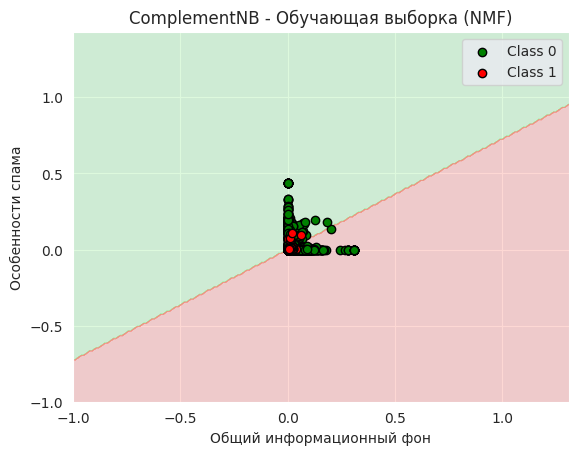

In [22]:

# Визуализация на обучающем наборе в пространстве, полученном с помощью NMF
plot_decision_boundary(clf_nmf, X_train_nmf, y_train, title="ComplementNB - Обучающая выборка (NMF)")

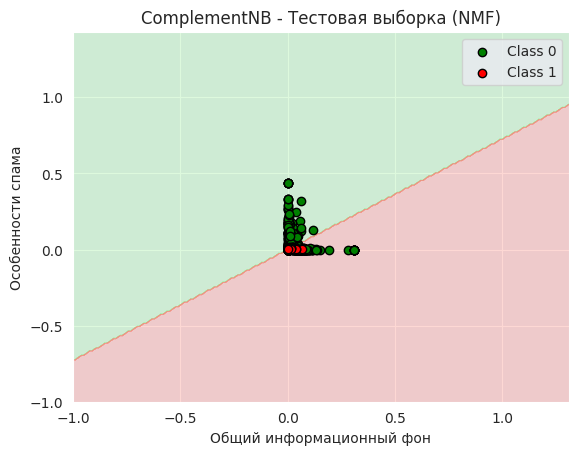

In [23]:

# Визуализация на тестовой выборке в пространстве, полученном с помощью NMF
plot_decision_boundary(clf_nmf, X_test_nmf, y_test, title="ComplementNB - Тестовая выборка (NMF)")

In [11]:


acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9318181818181818
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.93      0.96      1448
           1       0.67      0.97      0.79       224

    accuracy                           0.93      1672
   macro avg       0.83      0.95      0.88      1672
weighted avg       0.95      0.93      0.94      1672



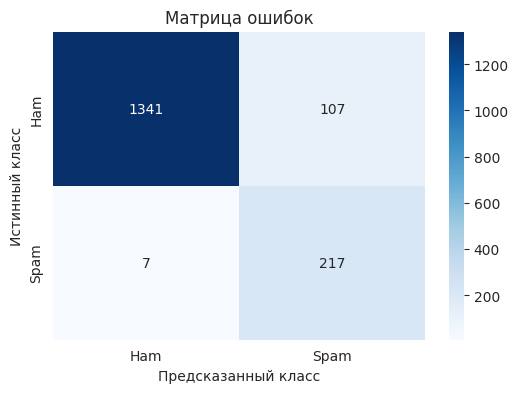

In [12]:

# Матрица ошибок
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.show()

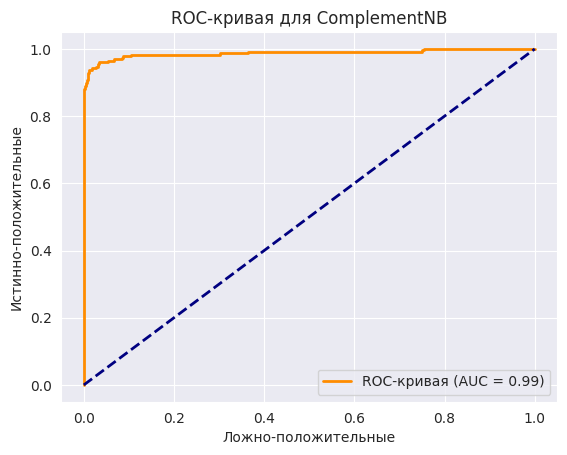

In [13]:

# ROC-кривая
y_proba = clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-кривая (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Ложно-положительные')
plt.ylabel('Истинно-положительные')
plt.title('ROC-кривая для ComplementNB')
plt.legend(loc='lower right')
plt.show()

In [14]:

# # Обучение модели ComplementNB на TF-IDF признаках показало точность ≈ 93.18%. Классификационный отчет демонстрирует высокие метрики для класса 0 (не спам), но
# несколько более низкие для класса 1 (спам). Матрица ошибок показывает, что модель ошибочно отнесла 107 примеров не спама к спаму, что указывает на наличие ложных
# срабатываний.
# Так как TF-IDF-признаки имеют высокую размерность, была применена техника NMF (негативное матричное разложение) для снижения размерности до 2D-пространства. Это
# позволило визуализировать данные и построить границы принятия решений. Функция plot_decision_boundary создает контурную заливку, показывающую области,
# классифицированные моделью, и накладывает на неё точки обучающей и тестовой выборок.
# Результаты показывают, что модель хорошо определяет не спам, но имеет некоторое снижение точности для спама, что может быть связано с дисбалансом классов.
# Визуализация решающих границ в 2D-пространстве (NMF) помогает оценить разделимость классов и понять, как модель принимает решения, что дополняет количественную
# оценку эффективности классификатора.
#
